In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


In [2]:
class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    ─────────────────────────────────────────────────────
    Forward : Bisection Method로 인장력 = 압축력 평형점(y_pna) 탐색
    Backward: Implicit Function Theorem(IFT)으로 ∂y_pna/∂coords 계산 후
              chain-rule을 통해 ∂Mp/∂coords 를 GNN까지 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        """
        coords    : [N, 2]  (x, y)
        t         : [N, 1]  두께
        fy        : [N, 1]  항복강도
        edge_index: [2, E]  (사용 안 하지만 인터페이스 유지)
        n_iter    : bisection 반복 횟수
        """
        # ── 1. Bisection으로 PNA 탐색 (no grad) ──
        with torch.no_grad():
            y = coords[:, 1]                       # [N]
            t_flat = t.squeeze(-1)                 # [N]
            fy_flat = fy.squeeze(-1)               # [N]

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                # 인장(위쪽) / 압축(아래쪽) 힘
                F_tens = torch.sum(t_flat * fy_flat * torch.clamp(y - y_mid, min=0.0))
                F_comp = torch.sum(t_flat * fy_flat * torch.clamp(y_mid - y, min=0.0))

                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)           # scalar tensor

        # ── 2. 전소성 모멘트 Mp = Σ A_i · fy_i · |y_i − y_pna| ──
        d = torch.abs(coords[:, 1] - y_pna)       # [N]
        area = t_flat                              # 단위 길이당 면적
        mp_pred = torch.sum(area * fy_flat * d)    # scalar

        # backward 에 필요한 텐서 저장
        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        """
        Implicit Function Theorem 적용
        ──────────────────────────────
        평형 조건  g(y_pna, coords) = F_tens − F_comp = 0

        IFT에 의해:
            ∂y_pna/∂y_i = − (∂g/∂y_i) / (∂g/∂y_pna)

        ∂Mp/∂y_i = A_i·fy_i·sign(y_i−y_pna)
                  + Σ_j A_j·fy_j·(−sign(y_j−y_pna)) · (∂y_pna/∂y_i)

        두 번째 항이 IFT 보정 항으로, PNA 이동에 의한 간접 효과를 반영합니다.
        """
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)   # scalar

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)

        s = torch.sign(y - y_pna)      # +1(인장), −1(압축)

        # ── ∂g/∂y_pna  (평형식의 y_pna에 대한 미분) ──
        #  g = Σ t·fy·clamp(y−y_pna,0) − Σ t·fy·clamp(y_pna−y,0)
        #  ∂g/∂y_pna = −Σ t·fy · 1[y>y_pna] − Σ t·fy · 1[y<y_pna]
        #            = −Σ t·fy  (y_pna 정확히 위의 노드 무시)
        dg_dy_pna = -torch.sum(t_flat * fy_flat)   # scalar (항상 음수)

        # ── ∂g/∂y_i ──
        #  i번째 노드가 인장(y_i>y_pna) → ∂g/∂y_i = +t_i·fy_i
        #  i번째 노드가 압축(y_i<y_pna) → ∂g/∂y_i = −t_i·fy_i  ⟹  = s_i · t_i · fy_i
        dg_dy = s * t_flat * fy_flat               # [N]

        # ── IFT: ∂y_pna/∂y_i = −dg_dy / dg_dy_pna ──
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)  # [N]

        # ── ∂Mp/∂y_i (직접 항 + IFT 보정 항) ──
        direct = t_flat * fy_flat * s                               # [N]
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy     # [N]
        dMp_dy = direct + indirect                                  # [N]

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None   # n_iter 추가로 5개


def calculate_mpl(coords, t, fy, edge_index):
    """Wrapper: ImplicitPNASolver.apply 호출"""
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)

In [3]:
## Model Architecture
## : C-GDN (Constraint-aware Graph Deformation Network)
##  - 표준 템플릿(Base Section)을 목표 Mp에 맞춰 **변형**하는 구조
##  - FiLM 레이어로 매 GATv2 블록에 Mp 조건 주입
##  - Hard constraint: 고정점 마스킹

class FiLMGenerator(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM)
    target_mp [B, 1] → (gamma, beta) [B, hidden]
    """
    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )

    def forward(self, target_mp):
        """target_mp: [1, 1] or [B, 1]"""
        out = self.net(target_mp)                       # [B, 2H]
        gamma, beta = torch.chunk(out, 2, dim=-1)       # [B, H] each
        return gamma, beta


class CGDNBlock(nn.Module):
    """
    단일 Message-Passing 블록
    GATv2Conv → FiLM modulation → LayerNorm → GELU → Residual
    """
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)

        # FiLM conditioning: γ ⊙ h + β
        h = gamma * h + beta

        h = self.norm(h)
        h = F.gelu(h)
        h = h + h_res   # residual
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network

    입력 노드 특징 (R^6):
        [x, y, is_fixed, layer_id, t, fy]

    엣지 특징 (R^4):
        [선분 길이, 각도, 레이어 ID, 플랜지 여부]

    조건부 입력:
        target_mp  (목표 전소성 모멘트)
    """

    def __init__(
        self,
        in_channels: int = 6,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,     # 최대 변위 클리핑 (mm)
    ):
        super().__init__()
        self.max_displacement = max_displacement

        # 1. Node Encoder ─────────────────────────
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        # 2. FiLM Generator (Mp 조건 주입) ────────
        self.film_gen = FiLMGenerator(hidden_channels)

        # 3. GATv2 Message-Passing Blocks ─────────
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        # 4. Coordinate Decoder ───────────────────
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),               # 출력: (Δx, Δy)
        )

    def forward(self, x, edge_index, edge_attr, target_mp, is_fixed_mask):
        """
        Parameters
        ----------
        x             : [N, 6]   노드 특징
        edge_index    : [2, E]
        edge_attr     : [E, 4]   엣지 특징
        target_mp     : [1, 1]   목표 전소성 모멘트
        is_fixed_mask : [N, 1]   고정점 Boolean 마스크

        Returns
        -------
        new_coords    : [N, 2]   변형 후 좌표
        delta_coords  : [N, 2]   변위 벡터
        """
        # ── Encode ──
        h = self.node_encoder(x)

        # ── FiLM parameters (한 번 생성, 모든 블록에 공유) ──
        gamma, beta = self.film_gen(target_mp)          # [1, H]

        # ── Message Passing ──
        for block in self.blocks:
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── Decode displacement ──
        delta_coords = self.decoder(h)                  # [N, 2]

        # 변위 클리핑 (안정성)
        delta_coords = torch.clamp(delta_coords,
                                   -self.max_displacement,
                                    self.max_displacement)

        # ── Hard Constraint: 고정점은 변위 = 0 ──
        delta_coords = delta_coords * (~is_fixed_mask).float()

        # ── 최종 좌표 = Base 좌표 + Δ ──
        new_coords = x[:, :2] + delta_coords

        return new_coords, delta_coords

In [4]:
## Loss Functions

def compute_smoothness_loss(new_coords, edge_index):
    src, dst = edge_index
    diff = new_coords[src] - new_coords[dst]
    return torch.mean(torch.norm(diff, dim=1) ** 2)

def compute_collision_loss(new_coords, layer_ids, margin=0.5):
    inner_mask = (layer_ids == 0)
    outer_mask = (layer_ids == 1)
    if inner_mask.sum() == 0 or outer_mask.sum() == 0:
        return torch.tensor(0.0, device=new_coords.device)

    inner_y = new_coords[inner_mask, 1]
    outer_y = new_coords[outer_mask, 1]
    gap_violation = torch.clamp(inner_y.max() - outer_y.min() + margin, min=0.0)
    return gap_violation ** 2

def compute_mass_loss(new_coords, t, edge_index):
    src, dst = edge_index
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)
    return area

In [5]:
def train_step(model, data, optimizer, target_mp_value,
               w_phys=1.0, w_smooth=0.1, w_mass=0.01,
               w_collision=1.0, w_fix=10.0):
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr

    is_fixed_mask = x[:, 2].bool().unsqueeze(1)
    layer_ids     = x[:, 3] 
    t             = x[:, 4].unsqueeze(1)
    fy            = x[:, 5].unsqueeze(1)

    target_mp = torch.tensor([[target_mp_value]], dtype=torch.float32, device=x.device)

    new_coords, delta_coords = model(x, edge_index, edge_attr, target_mp, is_fixed_mask)
    pred_mp = calculate_mpl(new_coords, t, fy, edge_index)

    l_phys = ((pred_mp - target_mp) / target_mp) ** 2
    l_smooth = compute_smoothness_loss(new_coords, edge_index)
    l_mass = compute_mass_loss(new_coords, t, edge_index)
    l_collision = compute_collision_loss(new_coords, layer_ids)
    
    fixed_nodes = is_fixed_mask.squeeze()
    l_fix = torch.sum(torch.norm(delta_coords[fixed_nodes], dim=1)) if fixed_nodes.any() else torch.tensor(0.0, device=x.device)

    loss = (w_phys * l_phys + w_smooth * l_smooth + w_mass * l_mass + 
            w_collision * l_collision + w_fix * l_fix)

    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "pred_mp": pred_mp.item(),
        "l_phys": l_phys.item(),
        "l_smooth": l_smooth.item(),
        "l_mass": l_mass.item(),
        "l_collision": l_collision.item(),
        "l_fix": l_fix.item() if isinstance(l_fix, torch.Tensor) else l_fix,
        "new_coords": new_coords.detach(),
    }

In [6]:
## run

if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # ── 모델 초기화 ──
    model = CGDN(
        in_channels=7, hidden_channels=128,
        num_layers=4, heads=4, edge_dim=4,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # ── 1. 노드 구성 설계 ──
    # 파트별 노드 수: 10개
    # 1층: 파트 1, 2, 3 (30 노드)
    # 2층: 파트 1, 2, 3 (30 노드)
    # 3층: 파트 1, 3 (20 노드) -> 총 80 노드
    num_nodes = 80
    # [x, y, is_fixed, part_id, level_id, t, fy]
    x = torch.zeros((num_nodes, 7), dtype=torch.float32)

    node_registry = {}  # (level, part, i) -> node_index 매핑용 딕셔너리
    current_idx = 0

    # 노드 생성 루프
    for level in [1, 2, 3]:
        parts_in_level = [1, 2, 3] if level in [1, 2] else [1, 3] # 3층은 2파트 제외
        
        for part in parts_in_level:
            for i in range(10):
                # ── 기하학적 초기 좌표 (x, y) 할당 ──
                # x좌표: 0 ~ 100mm 로 균등 분할
                x_coord = i * (100.0 / 9.0)
                
                # y좌표: x축(y=0) 기준 거리. 3파트(Inner)가 가장 가깝고, 1파트(Outer)가 가장 멉니다.
                # 양 끝점(i=0, i=9)은 모든 파트가 플랜지에서 만나도록 y=10으로 통일
                if i == 0 or i == 9:
                    y_coord = 10.0
                else:
                    if part == 3: y_coord = 20.0       # Inner
                    elif part == 2: y_coord = 35.0     # Reinf
                    elif part == 1: y_coord = 50.0     # Outer
                    
                # ── 고정점 (is_fixed) 마스킹 ──
                # 1파트와 3파트의 양 끝점은 절대 움직이지 않는 플랜지(고정점)로 간주
                is_fixed = 1.0 if (part in [1, 3] and (i == 0 or i == 9)) else 0.0
                
                # 물성치 (단순 가정)
                t = 1.5 if part != 2 else 2.0  # 보강재(2파트)는 두께 2.0mm
                fy = 1500.0 if part != 3 else 1200.0 # 파트별 강도 차등
                
                x[current_idx] = torch.tensor(
                    [x_coord, y_coord, is_fixed, part, level, t, fy]
                )
                node_registry[(level, part, i)] = current_idx
                current_idx += 1

    # ── 2. 엣지 (edge_index) 및 특성 (edge_attr) 구성 ──
    src_list, dst_list = [], []
    edge_attr_list = [] # [length, angle, part_id, edge_type (0=가로, 1=세로, 2=접합)]

    def add_edge(u, v, part_id, edge_type):
        """양방향 엣지를 추가하고 특성을 계산하는 헬퍼 함수"""
        src_list.extend([u, v])
        dst_list.extend([v, u])
        
        # 기하학적 특성 계산 (길이, 각도)
        dx = x[v, 0] - x[u, 0]
        dy = x[v, 1] - x[u, 1]
        length = math.sqrt(dx**2 + dy**2)
        angle = math.atan2(dy, dx)
        
        # 양방향 동일 특성 부여
        edge_attr_list.extend([[length, angle, part_id, edge_type], 
                                [length, -angle, part_id, edge_type]])

    # 2-1. 횡방향 엣지 (Intra-level): 같은 층, 같은 파트 내 연속된 노드 연결
    for level in [1, 2, 3]:
        parts = [1, 2, 3] if level in [1, 2] else [1, 3]
        for part in parts:
            for i in range(9):
                u = node_registry[(level, part, i)]
                v = node_registry[(level, part, i+1)]
                add_edge(u, v, part_id=part, edge_type=0.0)
                
    # 2-2. 플랜지 접합 (Flange Bind): 1파트와 3파트의 끝점 묶기
    for level in [1, 2, 3]:
        for i in [0, 9]:
            u = node_registry[(level, 1, i)] # 1파트 끝점
            v = node_registry[(level, 3, i)] # 3파트 끝점
            # part_id는 공통 접합부를 의미하는 0으로 부여
            add_edge(u, v, part_id=0.0, edge_type=2.0)

    # 2-3. 종방향 엣지 (Inter-level): 층간 동일 파트, 동일 인덱스 연결 (3D 연속성 확보)
    for level in [1, 2]:
        next_level = level + 1
        parts = [1, 2, 3] if level == 1 else [1, 3] # 2층->3층 갈때는 2파트 제외
        
        for part in parts:
            for i in range(10):
                u = node_registry[(level, part, i)]
                v = node_registry[(next_level, part, i)]
                add_edge(u, v, part_id=part, edge_type=1.0)

    # 텐서 변환
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long, device=device)
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32, device=device)

    x, edge_index, edge_attr
    print(f"Nodes: {x.shape} | Edges: {edge_index.shape} | Edge Features: {edge_attr.shape}")

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr).to(device)
    target_mp_req = 4500.0   ## 목표 전소성 모멘트 (kN·mm)

    # ── Training Loop ──
    print("=" * 60)
    print("C-GDN Training (Dummy Data)")
    print("=" * 60)
    for epoch in range(100):
        info = train_step(model, data, optimizer, target_mp_req)
        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {info['loss']:.4f} | "
                f"Mp: {info['pred_mp']:.1f} / {target_mp_req:.1f} | "
                f"L_phys: {info['l_phys']:.4f}  "
                f"L_smooth: {info['l_smooth']:.4f}  "
                f"L_mass: {info['l_mass']:.4f}  "
                f"L_collision: {info['l_collision']:.4f}"
                f"L_fix: {info['l_fix']:.4f}"
            )

Device: cuda
Nodes: torch.Size([80, 7]) | Edges: torch.Size([2, 256]) | Edge Features: torch.Size([256, 4])
C-GDN Training (Dummy Data)
Epoch 000 | Loss: 57.4057 | Mp: 3382.7 / 4500.0 | L_phys: 0.0616  L_smooth: 170.3997  L_mass: 4030.4067  L_collision: 0.0000L_fix: 0.0000
Epoch 010 | Loss: 51.4608 | Mp: 3021.7 / 4500.0 | L_phys: 0.1079  L_smooth: 138.0171  L_mass: 3755.1187  L_collision: 0.0000L_fix: 0.0000
Epoch 020 | Loss: 47.4916 | Mp: 2610.0 / 4500.0 | L_phys: 0.1764  L_smooth: 115.8904  L_mass: 3572.6145  L_collision: 0.0000L_fix: 0.0000
Epoch 030 | Loss: 44.9079 | Mp: 2047.5 / 4500.0 | L_phys: 0.2970  L_smooth: 102.1114  L_mass: 3439.9683  L_collision: 0.0000L_fix: 0.0000
Epoch 040 | Loss: 41.6730 | Mp: 1444.7 / 4500.0 | L_phys: 0.4610  L_smooth: 89.6907  L_mass: 3224.2954  L_collision: 0.0000L_fix: 0.0000
Epoch 050 | Loss: 40.7762 | Mp: 1694.3 / 4500.0 | L_phys: 0.3887  L_smooth: 86.1343  L_mass: 3177.4053  L_collision: 0.0000L_fix: 0.0000
Epoch 060 | Loss: 39.5856 | Mp: 1309.6

In [9]:
x

tensor([[0.0000e+00, 1.0000e+01, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [1.1111e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [2.2222e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [3.3333e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [4.4444e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [5.5556e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [6.6667e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [7.7778e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [8.8889e+01, 5.0000e+01, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.5000e+00,
         1.5000e+03],
        [1.0000e+02, 1.0000e+01, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.50

In [10]:
edge_index

tensor([[ 0,  1,  1,  2,  2,  3,  3,  4,  4,  5,  5,  6,  6,  7,  7,  8,  8,  9,
         10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19,
         20, 21, 21, 22, 22, 23, 23, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 29,
         30, 31, 31, 32, 32, 33, 33, 34, 34, 35, 35, 36, 36, 37, 37, 38, 38, 39,
         40, 41, 41, 42, 42, 43, 43, 44, 44, 45, 45, 46, 46, 47, 47, 48, 48, 49,
         50, 51, 51, 52, 52, 53, 53, 54, 54, 55, 55, 56, 56, 57, 57, 58, 58, 59,
         60, 61, 61, 62, 62, 63, 63, 64, 64, 65, 65, 66, 66, 67, 67, 68, 68, 69,
         70, 71, 71, 72, 72, 73, 73, 74, 74, 75, 75, 76, 76, 77, 77, 78, 78, 79,
          0, 20,  9, 29, 30, 50, 39, 59, 60, 70, 69, 79,  0, 30,  1, 31,  2, 32,
          3, 33,  4, 34,  5, 35,  6, 36,  7, 37,  8, 38,  9, 39, 10, 40, 11, 41,
         12, 42, 13, 43, 14, 44, 15, 45, 16, 46, 17, 47, 18, 48, 19, 49, 20, 50,
         21, 51, 22, 52, 23, 53, 24, 54, 25, 55, 26, 56, 27, 57, 28, 58, 29, 59,
         30, 60, 31, 61, 32,

In [11]:
edge_attr

tensor([[41.5145,  1.2998,  1.0000,  0.0000],
        [41.5145, -1.2998,  1.0000,  0.0000],
        [11.1111,  0.0000,  1.0000,  0.0000],
        ...,
        [ 0.0000, -0.0000,  3.0000,  1.0000],
        [ 0.0000,  0.0000,  3.0000,  1.0000],
        [ 0.0000, -0.0000,  3.0000,  1.0000]], device='cuda:0')

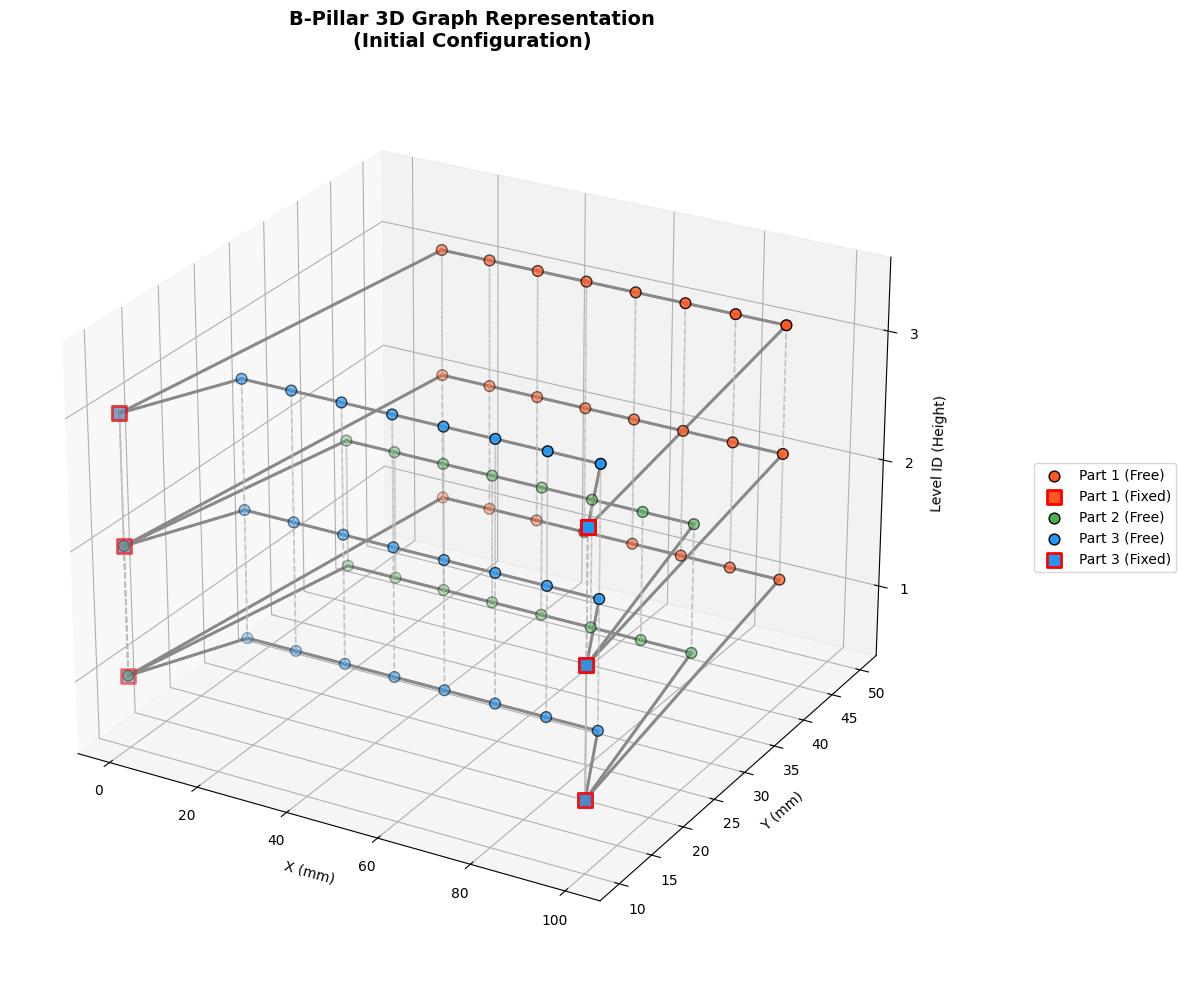

In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x_np = x.cpu().numpy()
ei_np = edge_index.cpu().numpy()
ea_np = edge_attr.cpu().numpy()

color_map = {1: '#FF5722', 2: '#4CAF50', 3: '#2196F3'} # Outer, Reinf, Inner

for i in range(ei_np.shape[1]):
    u = ei_np[0, i]
    v = ei_np[1, i]
    e_type = ea_np[i, 3]
    
    xs = [x_np[u, 0], x_np[v, 0]]
    ys = [x_np[u, 1], x_np[v, 1]]
    zs = [x_np[u, 4], x_np[v, 4]]
    
    if e_type == 0.0:
        ax.plot(xs, ys, zs, color='#888888', linestyle='-', linewidth=2.0, alpha=0.9)
    elif e_type == 1.0:
        ax.plot(xs, ys, zs, color='#BBBBBB', linestyle='--', linewidth=1.2, alpha=0.6)
    elif e_type == 2.0:
        ax.plot(xs, ys, zs, color='red', linestyle=':', linewidth=3.0, alpha=0.9)

for part_id in [1, 2, 3]:
    mask = (x_np[:, 3] == part_id) & (x_np[:, 2] == 0.0)
    ax.scatter(x_np[mask, 0], x_np[mask, 1], x_np[mask, 4], c=color_map[part_id], marker='o', s=60, edgecolors='k', label=f'Part {part_id} (Free)')
    
    mask_fixed = (x_np[:, 3] == part_id) & (x_np[:, 2] == 1.0)
    if mask_fixed.any():
        ax.scatter(x_np[mask_fixed, 0], x_np[mask_fixed, 1], x_np[mask_fixed, 4], c=color_map[part_id], marker='s', s=100, edgecolors='red', linewidths=2.0, label=f'Part {part_id} (Fixed)')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Level ID (Height)')
ax.set_title('B-Pillar 3D Graph Representation\n(Initial Configuration)', fontsize=14, fontweight='bold')

ax.set_zticks([1, 2, 3])
ax.set_zlim(0.5, 3.5)

# Fix viewing angle for better perspective
ax.view_init(elev=25, azim=-60)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()

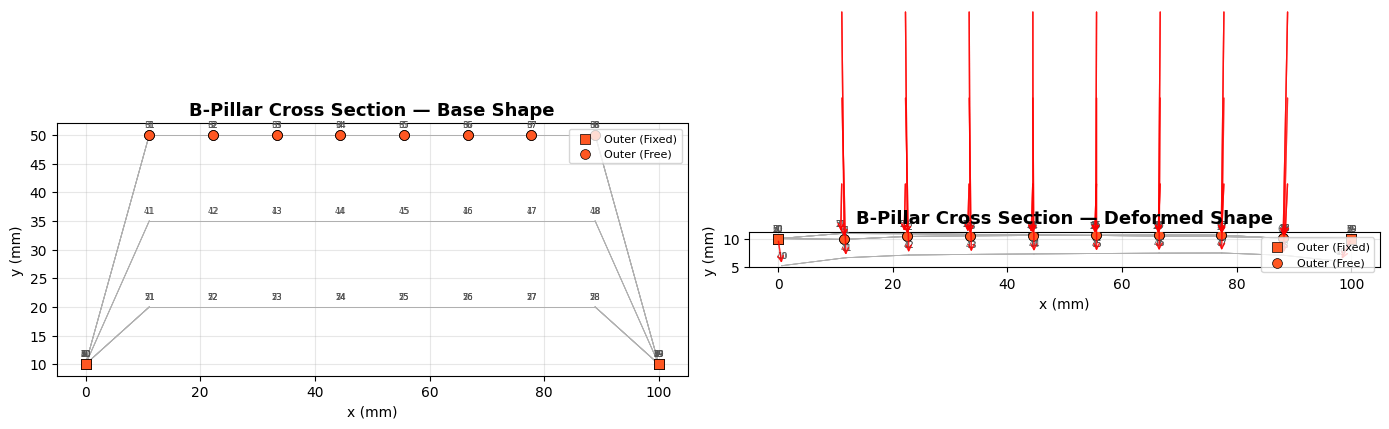

In [8]:
##  B-Pillar 단면 형상 시각화 (노드 & 엣지)

def visualize_section(coords, edge_index, x_features, title="B-Pillar Cross Section",
                      deformed_coords=None, figsize=(14, 7)):
    """
    Parameters
    ----------
    coords         : [N, 2]  노드 좌표 (x, y)
    edge_index     : [2, E]  엣지 인덱스
    x_features     : [N, 6]  노드 특징 [x, y, is_fixed, layer_id, t, fy]
    deformed_coords: [N, 2]  변형 후 좌표 (선택)
    """
    is_fixed  = x_features[:, 2].cpu().numpy().astype(bool)
    layer_ids = x_features[:, 3].cpu().numpy().astype(int)
    coords_np = coords.cpu().detach().numpy()
    ei = edge_index.cpu().numpy()

    n_plots = 2 if deformed_coords is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]

    def _draw(ax, pts, subtitle):
        # ── 엣지 그리기 ──
        for i in range(ei.shape[1]):
            s, d = ei[0, i], ei[1, i]
            ax.plot([pts[s, 0], pts[d, 0]],
                    [pts[s, 1], pts[d, 1]],
                    color='#b0b0b0', linewidth=0.6, zorder=1)

        # ── 노드 그리기 (레이어별 색상, 고정/자유 마커) ──
        colors_map = {0: '#2196F3', 1: '#FF5722'}   # Inner=파랑, Outer=주황
        marker_map = {True: 's', False: 'o'}         # 고정=사각, 자유=원
        label_map  = {True: 'Fixed', False: 'Free'}
        layer_name = {0: 'Inner', 1: 'Outer'}

        for lid in [0, 1]:
            for fix in [True, False]:
                mask = (layer_ids == lid) & (is_fixed == fix)
                if not mask.any():
                    continue
                lbl = f'{layer_name[lid]} ({label_map[fix]})'
                ax.scatter(pts[mask, 0], pts[mask, 1],
                           c=colors_map[lid],
                           marker=marker_map[fix],
                           s=50, edgecolors='k', linewidths=0.5,
                           zorder=3, label=lbl)

        # ── 노드 인덱스 표시 ──
        for i in range(len(pts)):
            ax.annotate(str(i), (pts[i, 0], pts[i, 1]),
                        fontsize=6, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points',
                        color='#555555')

        ax.set_title(subtitle, fontsize=13, fontweight='bold')
        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    # ── 원본(Base) 형상 ──
    _draw(axes[0], coords_np, f'{title} — Base Shape')

    # ── 변형(Deformed) 형상 ──
    if deformed_coords is not None:
        def_np = deformed_coords.cpu().detach().numpy()
        _draw(axes[1], def_np, f'{title} — Deformed Shape')

        # 변위 화살표 오버레이
        for i in range(len(coords_np)):
            dx = def_np[i, 0] - coords_np[i, 0]
            dy = def_np[i, 1] - coords_np[i, 1]
            if np.sqrt(dx**2 + dy**2) > 1e-4:
                axes[1].annotate('',
                    xy=(def_np[i, 0], def_np[i, 1]),
                    xytext=(coords_np[i, 0], coords_np[i, 1]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.0, alpha=0.6))

    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════════
#  시각화 실행
# ═══════════════════════════════════════════════════════════
base_coords = data.x[:, :2]              # 초기 좌표
deformed    = info['new_coords']         # 학습 후 변형 좌표

visualize_section(
    coords=base_coords,
    edge_index=data.edge_index,
    x_features=data.x,
    title='B-Pillar Cross Section',
    deformed_coords=deformed,
)